In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.svm import SVC

sns.set()

# Support Vector Machines
**Aprendizaje de Máquina - CEIA - FIUBA**

## SVC en Pima Indians Diabetes

Para practicar con un dataset real usemos el dataset [**Pima Indians Diabetes**](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database), el cual contiene datos clínicos de **768 mujeres de la comunidad Pima** (una comunidad indígena del sur de Arizona con alta incidencia de diabetes tipo 2), con 8 atributos de variables fisiológicas. Además contamos con una columna de valores binarios llamada **diabetes** que nos indica si la paciente tiene diabetes o no.

In [2]:
# Cargamos el dataset
df_pima = pd.read_csv("datasets/pima_diabetes.csv")

In [3]:
df_pima.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   embarazos         768 non-null    int64  
 1   glucosa           768 non-null    int64  
 2   presion_arterial  768 non-null    int64  
 3   grosor_piel       768 non-null    int64  
 4   insulina          768 non-null    int64  
 5   imc               768 non-null    float64
 6   funcion_pedigri   768 non-null    float64
 7   edad              768 non-null    int64  
 8   diabetes          768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Veamos la distribución de la variable objetivo.

In [4]:
df_pima.diabetes.value_counts()

diabetes
0    500
1    268
Name: count, dtype: int64

In [5]:
df_pima.head()

,embarazos,glucosa,presion_arterial,grosor_piel,insulina,imc,funcion_pedigri,edad,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Las clases están moderadamente desbalanceadas (aproximadamente 65% / 35%), por lo que la exactitud (accuracy) puede ser engañosa. Voy a usar F1-Score como métrica de evaluación.

---
Trabajemos en el modelo.

Todas las variables son numéricas, por lo que no debemos hacer nada para adaptarlas, más que normalizarlas. Para este caso vamos a usar todos los atributos.

In [6]:
# Los ceros en columnas como glucosa, insulina o imc son datos no medidos
# enmascarados como 0 (ver la notebook de EDA). Los mantenemos tal cual, sin
# imputar, para no alterar el dataset original.
X = df_pima.drop(columns='diabetes')
y = df_pima['diabetes']

In [7]:
# Mismo split que la notebook de hiper-parámetros (clase 2) para poder comparar:
# estratificado por y, test_size=0.25 y random_state=0
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25,
    random_state = 0, stratify = y)

In [8]:
from sklearn.preprocessing import StandardScaler

sc_x = StandardScaler()
X_train = sc_x.fit_transform(X_train)
X_test = sc_x.transform(X_test)

Vamos a hacer una búsqueda de grilla para buscar qué modelo se ajustaría mejor.

In [9]:
svm_pima = SVC()

grid = GridSearchCV(svm_pima,
                    [{"C": [0.01, 0.1, 1, 5, 10, 100], "kernel": ["linear"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], 
                      "gamma": [0.1, 0.5, 1, 2, 10, 100], "kernel": ["rbf"]},
                     {"C": [0.01, 0.1, 1, 5, 10, 100], "degree": [2, 3, 4, 5, 6], 
                      "kernel": ["poly"]}],
                    refit=True,
                    cv=5,
                    scoring='f1')
grid.fit(X_train, y_train)

,estimator,SVC()
,param_grid,"[{'C': [0.01, 0.1, ...], 'kernel': ['linear']}, {'C': [0.01, 0.1, ...], 'gamma': [0.1, 0.5, ...], 'kernel': ['rbf']}, ...]"
,scoring,'f1'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [10]:
grid.best_params_

{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

Elegido el mejor modelo y entrenado, podemos ver el estado.

In [11]:
svm_pima_best = grid.best_estimator_

Y podemos ver las diferentes métricas que nos dio con el dataset de testeo.

In [12]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

y_pred = svm_pima_best.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"La exactitud de clasificación es: {accuracy}")
print(f"F1-score de testeo fue: {f1}")
print(f"Precisión de testeo fue: {precision}")
print(f"Recall de testeo fue: {recall}")

La exactitud de clasificación es: 0.78125
F1-score de testeo fue: 0.6612903225806451
Precisión de testeo fue: 0.7192982456140351
Recall de testeo fue: 0.6119402985074627


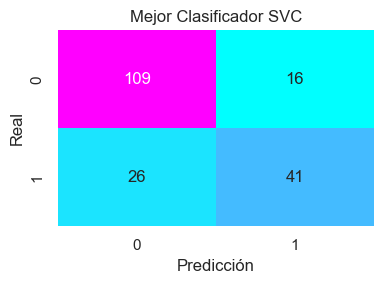

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=svm_pima_best.classes_)

fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt="d", cmap="cool", cbar=False, ax=ax,
            xticklabels=svm_pima_best.classes_,
            yticklabels=svm_pima_best.classes_)
ax.set_title("Mejor Clasificador SVC")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

Algo que podemos hacer con los SVM es obtener la curva ROC.

/Users/facundolucianna/Docencia/UBA/Aprendizaje de Maquina I/Repo/aprMaqI_CEIA/.venv/lib/python3.13/site-packages/sklearn/utils/_plotting.py:175: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


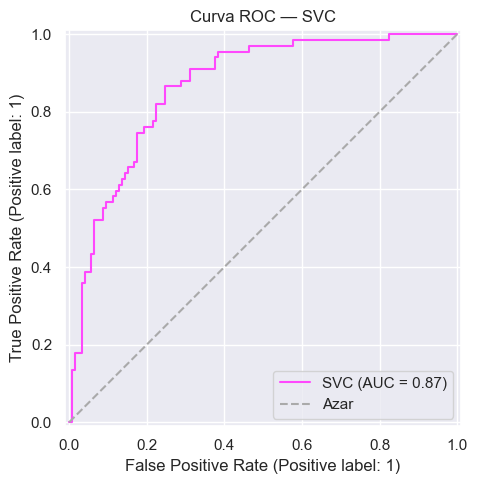

In [14]:
from sklearn.metrics import RocCurveDisplay

fig, ax = plt.subplots(figsize=(5, 5))
svc_disp = RocCurveDisplay.from_estimator(svm_pima_best, X_test, y_test, ax=ax,
                                          color="#ff48fd")
ax.plot([0, 1], [0, 1], linestyle="--", color="#aaaaaa", label="Azar")
ax.set_title("Curva ROC — SVC")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Como vemos, el clasificador SVC para este dataset nos da un valor de AUC razonable, aunque más modesto que en datasets más separables — Pima Indians Diabetes es un problema notoriamente difícil, en parte por los valores faltantes enmascarados como ceros (ver la notebook de EDA).

---
## Comparativa final entre todos los casos

A lo largo de la **clase 2** y la **clase 3** entrenamos varios modelos sobre el mismo dataset (Pima Indians Diabetes) y con el **mismo split** (`test_size=0.25`, `random_state=0`, `stratify=y`), lo que nos permite compararlos de forma directa sobre el mismo conjunto de testeo:

- **Baseline (umbral de glucosa)** — regla heurística derivada del EDA: `glucosa` es el predictor más discriminativo. No requiere entrenamiento y funciona como piso de referencia.
- **Mejor KNN** — el mejor clasificador k-NN encontrado en la clase 2 entre búsqueda por grilla, aleatoria, bayesiana y Optuna. El mejor F1 lo obtuvo la búsqueda con **Optuna** (`n_neighbors=3`, `weights='uniform'`, `p≈3.76`).
- **Regresión Logística** — modelo lineal clásico entrenado en la notebook auxiliar [`clase2/jupyter_notebooks/Auxiliar - Regresion Logistica.ipynb`](../../clase2/jupyter_notebooks/Auxiliar%20-%20Regresion%20Logistica.ipynb) (`C=0.01`, `penalty='l2'`), reproducido aquí con el mismo split.
- **SVC (RBF)** — el mejor SVM encontrado en este notebook.

In [15]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline

# X_train / X_test ya fueron estandarizados más arriba. Rehacemos el split SIN
# escalar (mismos parámetros -> mismo conjunto de test) para el baseline, el KNN
# y la regresión logística, que necesitan los valores originales.
X_raw = df_pima.drop(columns='diabetes')
X_raw_train, X_raw_test, _, _ = train_test_split(
    X_raw, y, test_size=0.25, random_state=0, stratify=y)

# --- 1) Baseline: umbral de glucosa (predictor más discriminativo según el EDA) ---
glucosa_sin = df_pima.loc[df_pima["diabetes"] == 0, "glucosa"]
glucosa_con = df_pima.loc[df_pima["diabetes"] == 1, "glucosa"]
umbral_glucosa = (glucosa_sin.median() + glucosa_con.median()) / 2
y_pred_baseline = (X_raw_test["glucosa"] > umbral_glucosa).astype(int)

# --- 2) Mejor KNN de la clase 2 (encontrado con Optuna) ---
best_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', KNeighborsClassifier(n_neighbors=3, weights='uniform',
                                        p=3.758948544078171))
])
best_knn.fit(X_raw_train, y_train)
y_pred_knn = best_knn.predict(X_raw_test)

# --- 3) Regresión logística (notebook auxiliar de la clase 2) ---
best_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=0.01, penalty='l2', solver='liblinear',
                                 max_iter=5000))
])
best_logreg.fit(X_raw_train, y_train)
y_pred_logreg = best_logreg.predict(X_raw_test)

# --- 4) Mejor SVC de este notebook (X_test ya está estandarizado) ---
y_pred_svc = svm_pima_best.predict(X_test)

modelos = ["Baseline (umbral glucosa)", "Mejor KNN (Optuna)",
           "Regresión Logística", "SVC (RBF)"]
preds = [y_pred_baseline, y_pred_knn, y_pred_logreg, y_pred_svc]

df_cmp = pd.DataFrame({
    "F1-score": [f1_score(y_test, yp) for yp in preds],
    "Exactitud balanceada": [balanced_accuracy_score(y_test, yp) for yp in preds],
    "Precisión": [precision_score(y_test, yp, zero_division=0) for yp in preds],
    "Recall": [recall_score(y_test, yp, zero_division=0) for yp in preds],
}, index=pd.Index(modelos))

df_cmp.round(4)

,F1-score,Exactitud balanceada,Precisión,Recall
Baseline (umbral glucosa),0.6533,0.7297,0.5904,0.7313
Mejor KNN (Optuna),0.6230,0.7156,0.6909,0.5672
Regresión Logística,0.6341,0.7230,0.6964,0.5821
SVC (RBF),0.6613,0.7420,0.7193,0.6119


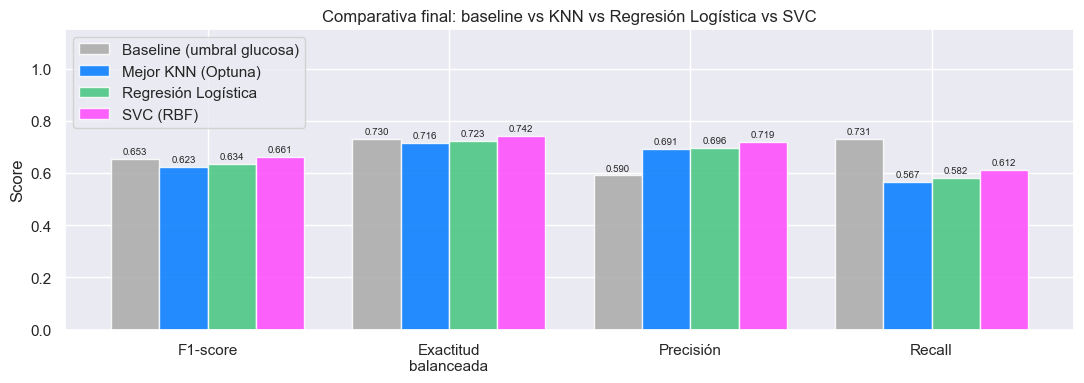

In [16]:
colores = ["#aaaaaa", "#007aff", "#44c57f", "#ff48fd"]
metric_labels = ["F1-score", "Exactitud\nbalanceada", "Precisión", "Recall"]
x = np.arange(len(metric_labels))
n = len(modelos)
width = 0.8 / n

fig, ax = plt.subplots(figsize=(11, 4))
for i, (modelo, color) in enumerate(zip(modelos, colores)):
    bars = ax.bar(
        x + (i - (n - 1) / 2) * width,
        df_cmp.iloc[i],
        width,
        label=modelo,
        color=color,
        alpha=0.85,
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=7)

ax.set_ylim(0, 1.15)
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylabel("Score")
ax.set_title("Comparativa final: baseline vs KNN vs Regresión Logística vs SVC")
ax.legend()
plt.tight_layout()
plt.show()

### Observaciones

- El **SVC (RBF)** es el mejor modelo entrenado hasta ahora: obtiene el mayor **F1-score (0.66)**, la mayor **exactitud balanceada (0.74)** y la mayor **precisión (0.72)**, superando al resto.
- El **baseline de glucosa**, a pesar de ser una única regla sin entrenamiento, sigue siendo muy competitivo: es el que mayor **recall (0.73)** consigue — detecta más pacientes con diabetes, aunque a costa de más falsos positivos (menor precisión). Confirma lo que anticipaba el EDA: `glucosa` concentra gran parte de la señal del problema.
- La **regresión logística** (modelo lineal simple) queda por encima del mejor KNN en F1 (0.63 vs 0.62) y es la segunda en precisión y exactitud balanceada. Un modelo lineal bien regularizado es un competidor serio, barato e interpretable.
- El **mejor KNN (Optuna)** queda último en F1 entre los modelos entrenados: en un dataset chico y difícil como Pima, un modelo más flexible no garantiza mejores resultados.